# Iris Flower Classification

**Objective:** Train a machine learning model to identify the species of an iris flower (Setosa, Versicolor, or Virginica) from its physical measurements.

**Author:** Prajna K V

## 1. Load the Dataset

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["species_name"] = df["species"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Exploratory Data Analysis (EDA)

Check data shape, types, missing values, and descriptive statistics before doing anything else.

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (150, 6)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Check class balance - important to know if any species is underrepresented
df["species_name"].value_counts()

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**Observation:** No missing values (150 non-null across all columns). The dataset is perfectly balanced with 50 samples per species.

## 3. Visualizations

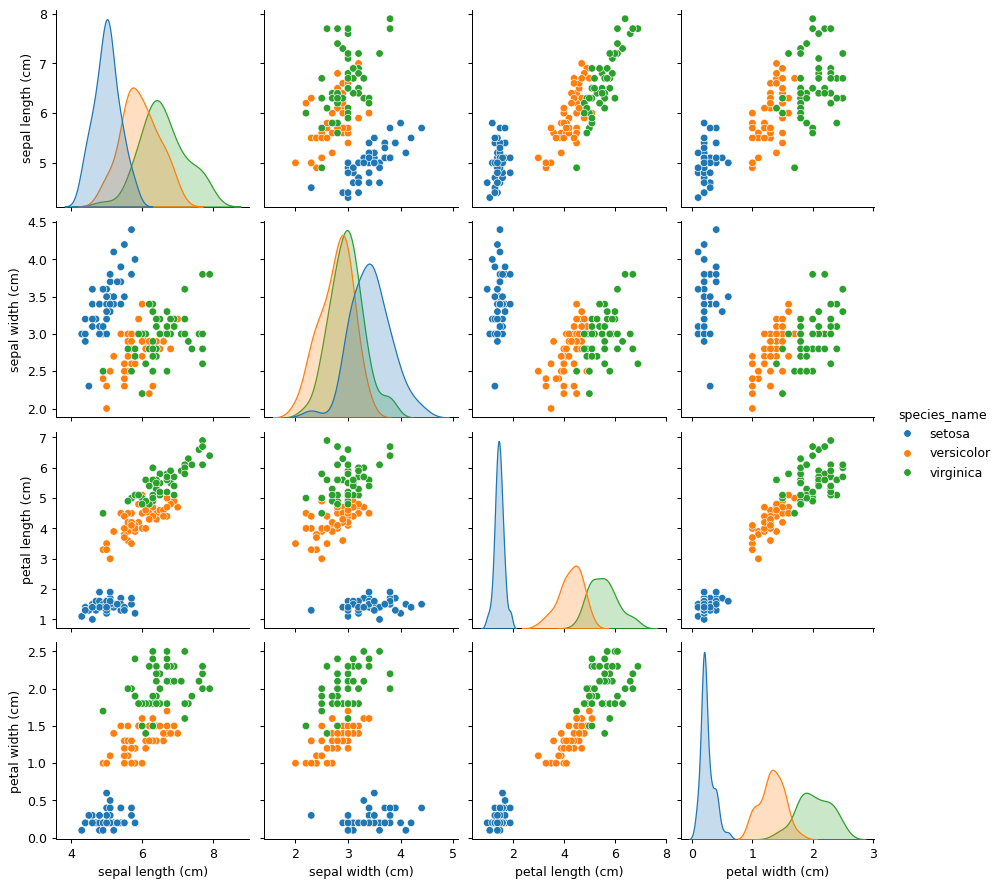

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(df, hue="species_name", vars=iris.feature_names)
plt.show()

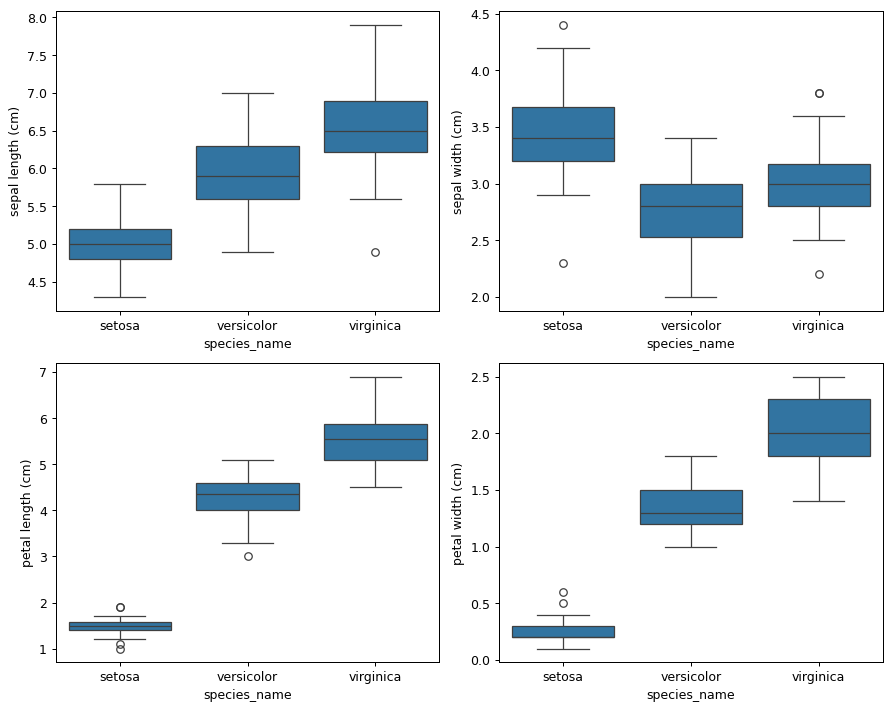

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(data=df, x="species_name", y=col, ax=ax)
plt.tight_layout()
plt.show()

**Observation:** Petal length and petal width show the clearest separation between species, especially for Setosa which is distinctly separate from the other two. Sepal measurements overlap more between Versicolor and Virginica, making them less useful on their own for classification.

## 4. Feature Selection

Based on the visualizations above, **petal length and petal width are the most discriminative features** since they show the least overlap between species classes. Sepal measurements are more useful in combination with petal measurements rather than alone.

## 5. Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 120
Test samples: 30


## 6. Train Classifiers

We train two different classifiers to compare performance: Logistic Regression and K-Nearest Neighbors (KNN).

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
knn_pred = knn_model.predict(X_test)
print("Models trained and predictions generated.")

Models trained and predictions generated.


## 7. Model Evaluation

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(confusion_matrix(y_test, log_pred))
print(classification_report(y_test, log_pred, target_names=iris.target_names))

=== Logistic Regression ===
Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [10]:
print("=== K-Nearest Neighbors ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred, target_names=iris.target_names))

=== K-Nearest Neighbors ===
Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 8. Conclusion

Both **Logistic Regression** and **K-Nearest Neighbors** achieved **100% accuracy** on the test set. This is expected given the Iris dataset's strong class separation, particularly in petal measurements.

**Best model:** Logistic Regression is selected as the preferred model for this task. While both models perform identically here, Logistic Regression is simpler, faster to train, and more interpretable, making it the more practical choice for deployment.